# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

### In Your Response:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?



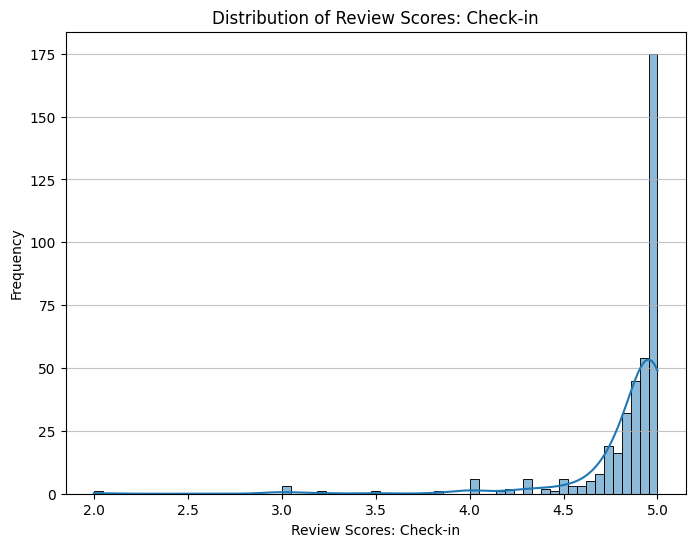

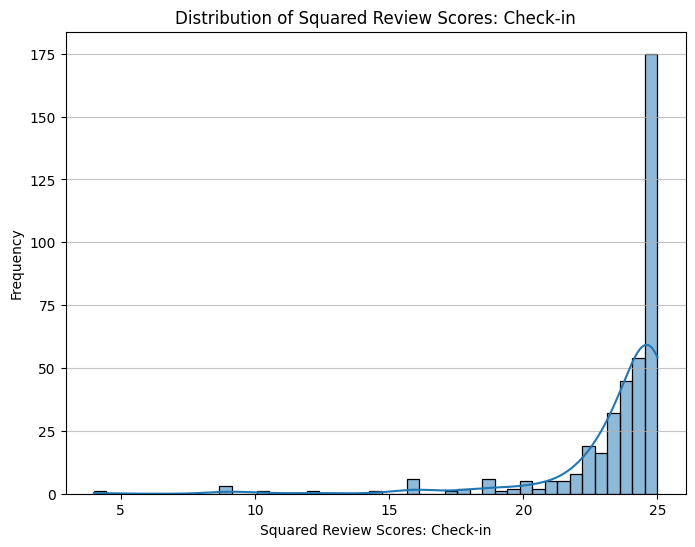

In [15]:
plt.figure(figsize=(8, 6))
sns.histplot(df['review_scores_checkin'], kde=True)
plt.title('Distribution of Review Scores: Check-in')
plt.xlabel('Review Scores: Check-in')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Apply square transformation to reduce left skewness
df['review_scores_checkin_squared'] = np.square(df['review_scores_checkin'])

plt.figure(figsize=(8, 6))
sns.histplot(df['review_scores_checkin_squared'], kde=True)
plt.title('Distribution of Squared Review Scores: Check-in')
plt.xlabel('Squared Review Scores: Check-in')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### ✍️ Your Response: 🔧
1. I examined "review_scores_checkin"

2. I chose to apply the square transformation. I chose to use this transformation because it is suposed to help reduce left skewed data.

3. Due to the fact that the data was already heavliy skewed, there was not a huge impact on model usablility. The only real benifit was that the chart is not as large and the numbers are closer together.

## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

### In Your Response:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

In [16]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Min-Max scale 'price'
scaler_minmax = MinMaxScaler()
df['price_minmax_scaled'] = scaler_minmax.fit_transform(df[['price']])

# Z-score scale 'review_scores_rating'
scaler_standard = StandardScaler()
df['review_scores_rating_zscore'] = scaler_standard.fit_transform(df[['review_scores_rating']])

### ✍️ Your Response: 🔧
1. I chose to sclae "price", and "review_scores_rating".

2. These scaled values may be more useful than the originals when explaing the data to outsiders. You can tell someone what the mean of the data set is, but that does not give an inside into how the data works. Scaling the data can help one better expalin to others what is going on.

3. People who are invested in Airbnb are most likely to benifit from this data transfomation. This is because this transformations will allow them to have a better insight into what the data actully means.

## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

### In Your Response:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?


In [17]:
df['price_category'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')
print(df[['price', 'price_category']].head())

   price price_category
0   70.0            Low
1  104.0         Medium
2   75.0            Low
3  101.0         Medium
4  110.0           High


### ✍️ Your Response: 🔧
1.The column that I group was "price". I used Three categories: Low, Medium, and High.

2. Someone might prefer this grouped veiw rather than raw numbers due to the larger variation in numbers in this colunm. Putting price in terms of low - high allows anyone to easily interprent the data.

3. Grouping the data like this benifits many people at Airbnb. This includes customers, anyalist, and executuive board members.

## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

### In Your Response:
1. What two new columns did you create?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

In [18]:
# Create 'potential_revenue_min_stay' column
df['potential_revenue_min_stay'] = df['price'] * df['minimum_nights']

# Create 'rental_type' column based on minimum_nights
df['rental_type'] = np.where(df['minimum_nights'] >= 30, 'Long-Term', 'Short-Term')

print("New columns created: 'potential_revenue_min_stay' and 'rental_type'")
print(df[['price', 'minimum_nights', 'potential_revenue_min_stay', 'rental_type']].head())

New columns created: 'potential_revenue_min_stay' and 'rental_type'
   price  minimum_nights  potential_revenue_min_stay rental_type
0   70.0              28                      1960.0  Short-Term
1  104.0               2                       208.0  Short-Term
2   75.0               2                       150.0  Short-Term
3  101.0               2                       202.0  Short-Term
4  110.0               1                       110.0  Short-Term


### ✍️ Your Response: 🔧 🔧
1. I chose to create a "potential revenue" column and "rental type" column.

2. These columns would be used by customers and employees to determine what kind of places they are staying at, and how much diffrent locations are making. Customers may want to invest in Airbnb, and the best way to do that is to know what the market looks like.

3. Both of these new columns provide a deeper insight into the Airbnb market and help employees and consumers make better decisions about where to invest in properties.



## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

### ✍️ In your markdown:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?



In [24]:
if 'property_type' in df.columns:
    property_type_encoded = pd.get_dummies(df['property_type'], prefix='property_type', dtype=int)
    df = pd.concat([df, property_type_encoded], axis=1)

    print("One-hot encoded 'property_type' columns added to DataFrame:")
    # Dynamically select columns for printing to avoid KeyError if certain property types don't exist
    cols_to_print = ['property_type'] + [col for col in df.columns if col.startswith('property_type_') and col != 'property_type']
    print(df[cols_to_print].head())
else:
    print("Error: 'property_type' column not found in the DataFrame. Please ensure your dataset includes this column and that the data loading step was executed successfully.")

One-hot encoded 'property_type' columns added to DataFrame:
        property_type  property_type_Entire condo  \
0  Entire rental unit                           0   
1  Entire rental unit                           0   
2  Entire rental unit                           0   
3  Entire rental unit                           0   
4  Entire rental unit                           0   

   property_type_Entire cottage  property_type_Entire guest suite  \
0                             0                                 0   
1                             0                                 0   
2                             0                                 0   
3                             0                                 0   
4                             0                                 0   

   property_type_Entire guesthouse  property_type_Entire home  \
0                                0                          0   
1                                0                          0   
2          

### ✍️ Your Response: 🔧
1. I chose to encode "property_type". I chose this beacuse it is the most model ready variable in the dataset.
2. I used the One-hot encodining methood.
3. This transformation could help in a bussnies report scenario by allowing shareholders and board members to better understand the data. The more effectivly we can portey data to others, the better we can satisfiy people and midigate confusion.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [31]:
df.to_csv("cleaned_airbnb_data_7_cleaned.csv", index=False)

## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### In Your Response:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. The most intresting transformation that I worked with was scaling the data. This was cool because it give data more meaning and allows someone to get a better idea of the dataset without looking at graphs or models.

2. The most useful changes to a host analyst or city planner would be the transfomations into categories. For the sake of most people, categories are the most useful and practical way to look at data. Someone with no knowlage of what numbers should look like are able to determine if something is good, bad, or average.

3. If I was going to biuld a dashboard with this data, I would convert it all into simple yet useful data types such as categories— or I would bin a lot of the numeric data columns. This would allow me to make the data set as simple as posiable for anyone to read. The easier it is to read the data, the less confusion there is when other people try to use it.

4. Doing this relates to my customized learning outcome in Canvas, because I talked about how I wanted to anaylize and model realestate throughtout the states and diffrent area. I want to make it easier to visualize the data and inform investors of diffrent opportunities.



## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [32]:
!jupyter nbconvert --to html "assignment_07_data_transformation_TettelbachIan.ipynb"

[NbConvertApp] Converting notebook assignment_07_data_transformation_TettelbachIan.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 395165 bytes to assignment_07_data_transformation_TettelbachIan.html
